# Clustering

**Pipeline:**
1. Feature definitions — `feature_cols` (26), `socio_cols` (7), `non_socio_cols` (19)
2. Preprocessing — sentinel fix, median imputation, StandardScaler
3. PCA — compare explained variance across full / socio / non-socio
4. K-Means — elbow method, select K, compare socio vs non-socio cluster impact
5. Interpretation of K-Means
6. Other clustering methods

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# from google.colab import drive
# drive.mount('/content/drive')

data = pd.read_csv('data/V2merged_data_clean.csv')
print(f'Loaded: {data.shape[0]:,} rows x {data.shape[1]} columns')

TARGET = 'Energy Burden (% income)'
VARIANCE_THRESHOLD = 0.9 
HIGH_BURDEN = 6.0

Loaded: 2,212 rows x 37 columns


## 1. Feature Definitions

In [3]:
feature_cols = [
    'pluto_mean_yearbuilt', 'pluto_mean_builtfar',
    'pluto_bldgarea_per_unit', 'pluto_resarea_per_unit',
    'pluto_avg_lotarea', 'pluto_commercial_share', 'pluto_pct_residential',
    'canopy_treecanopy', 'canopy_temp_diff',
    'subway_05mi', 'bus_025mi',
    'median_income', 'pct_nonwhite', 'pct_renter', 'avg_hh_size',
    'pct_rent_burdened', 'Total Households'
]

socio_cols = [
    'median_income', 'pct_nonwhite', 'pct_renter',
    'avg_hh_size', 'pct_rent_burdened', 'Total Households'
]

non_socio_cols = [c for c in feature_cols if c not in socio_cols]

print(f'Total features:     {len(feature_cols)}')
print(f'Socio features:     {len(socio_cols)}')
print(f'Socio cols: {socio_cols}')
print(f'\nNon-socio features: {len(non_socio_cols)}')
print(f'Non-socio cols: {non_socio_cols}')

Total features:     17
Socio features:     6
Socio cols: ['median_income', 'pct_nonwhite', 'pct_renter', 'avg_hh_size', 'pct_rent_burdened', 'Total Households']

Non-socio features: 11
Non-socio cols: ['pluto_mean_yearbuilt', 'pluto_mean_builtfar', 'pluto_bldgarea_per_unit', 'pluto_resarea_per_unit', 'pluto_avg_lotarea', 'pluto_commercial_share', 'pluto_pct_residential', 'canopy_treecanopy', 'canopy_temp_diff', 'subway_05mi', 'bus_025mi']


## 2. Preprocessing

- Replace sentinel values (`-666666666` encodes missing — confirmed in `RF_Initial.ipynb`)
- Median imputation — keeps all ~2,200 tracts, consistent with RF model
- `StandardScaler` — required before PCA and distance-based clustering

In [4]:
# Drop rows with missing/zero energy burden (non-residential tracts)
data = data[data[TARGET].notna() & (data[TARGET] > 0)].reset_index(drop=True)
y = data[TARGET].values
print(f'Rows after removing missing/zero target: {len(y):,}')

X_raw = data[feature_cols].copy()

# Replace sentinel values
sentinel_cols = [c for c in feature_cols if X_raw[c].min() < -1000]
for col in sentinel_cols:
    n_bad = (X_raw[col] < -1000).sum()
    X_raw[col] = X_raw[col].where(X_raw[col] > -1000, np.nan)
    print(f'  Replaced {n_bad} sentinel values in {col}')

X_raw['pluto_commercial_share'] = X_raw['pluto_commercial_share'].fillna(0)

# Median imputation
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)

# Scale each feature set
X_scaled          = StandardScaler().fit_transform(X_imp[feature_cols])
X_socio_scaled    = StandardScaler().fit_transform(X_imp[socio_cols])
X_nonsocio_scaled = StandardScaler().fit_transform(X_imp[non_socio_cols])

print(f'\nFull matrix:      {X_scaled.shape}')
print(f'Socio matrix:     {X_socio_scaled.shape}')
print(f'Non-socio matrix: {X_nonsocio_scaled.shape}')
print(f'Missing values:   {np.isnan(X_scaled).sum()}')

Rows after removing missing/zero target: 2,212
  Replaced 23 sentinel values in median_income
  Replaced 1 sentinel values in avg_hh_size

Full matrix:      (2212, 17)
Socio matrix:     (2212, 6)
Non-socio matrix: (2212, 11)
Missing values:   0


## 3. PCA

Running PCA on all three feature sets (target: ≥85% explained variance)

In [5]:
pca = PCA(random_state=42)
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
N_COMPONENTS = int(np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD)) + 1

print(f"Components required to reach {VARIANCE_THRESHOLD*100}% variance: {N_COMPONENTS}")

X_pca = PCA(n_components=N_COMPONENTS, random_state=42).fit_transform(X_scaled)

Components required to reach 90.0% variance: 11


## 4. K-Means Clustering

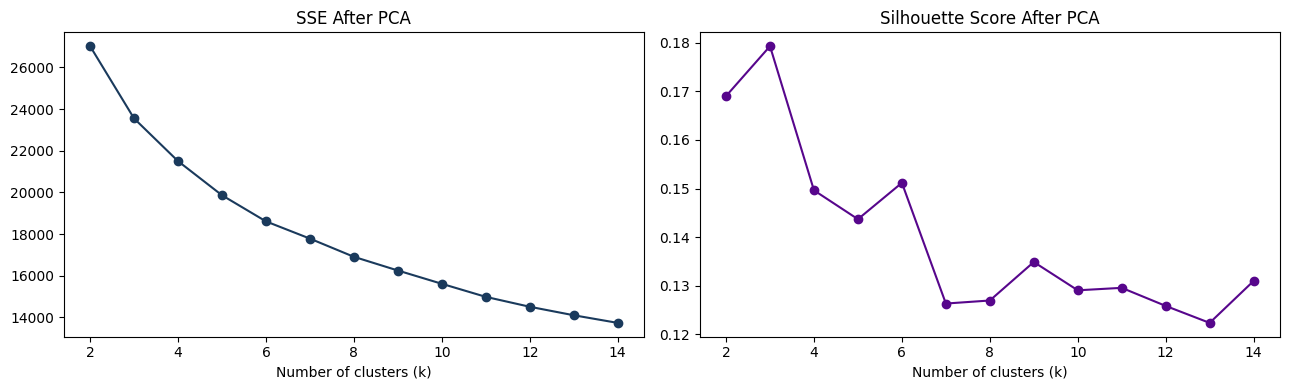

In [6]:
K_range = range(2, 15)
inertias = []
sils = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='#1A3A5C')
axes[0].set_title(f'SSE After PCA')
axes[0].set_xlabel('Number of clusters (k)')
axes[1].plot(list(K_range), sils, 'o-', color='#57068C')
axes[1].set_title(f'Silhouette Score After PCA')
axes[1].set_xlabel('Number of clusters (k)')
plt.tight_layout()
# plt.savefig('elbow_silhouette.png')

In [7]:
km_store = {}

for k in [2, 3, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    lbl = km.labels_

    sil    = silhouette_score(X_pca, lbl)
    ch     = calinski_harabasz_score(X_pca, lbl)
    db     = davies_bouldin_score(X_pca, lbl)
    means  = sorted([round(float(y[lbl == c].mean()), 2) for c in np.unique(lbl)])
    sizes  = [int((lbl == c).sum()) for c in np.unique(lbl)]

    print(f"k = {k}")
    print(f"  Silhouette        = {round(sil, 4)}  (higher = better)")
    print(f"  Calinski-Harabasz = {round(ch, 1)}  (higher = better)")
    print(f"  Davies-Bouldin    = {round(db, 4)}  (lower  = better)")
    print(f"  Cluster sizes     = {sizes}\n")

    km_store[k] = {'lbl': lbl, 'sil': sil, 'ch': ch, 'db': db}

k = 2
  Silhouette        = 0.169  (higher = better)
  Calinski-Harabasz = 421.5  (higher = better)
  Davies-Bouldin    = 2.0493  (lower  = better)
  Cluster sizes     = [941, 1271]

k = 3
  Silhouette        = 0.1793  (higher = better)
  Calinski-Harabasz = 404.4  (higher = better)
  Davies-Bouldin    = 1.8186  (lower  = better)
  Cluster sizes     = [354, 645, 1213]

k = 6
  Silhouette        = 0.1512  (higher = better)
  Calinski-Harabasz = 321.7  (higher = better)
  Davies-Bouldin    = 1.5914  (lower  = better)
  Cluster sizes     = [211, 162, 674, 723, 380, 62]



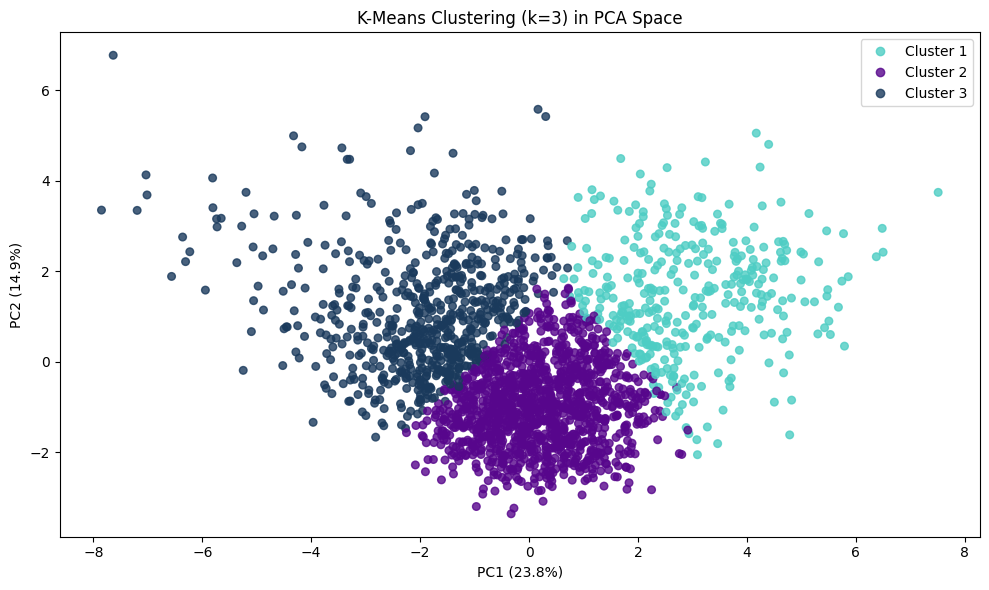

In [8]:
K_CHOSEN = 3

KM_FINAL = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
KM_FINAL.fit(X_pca)

_cluster_means = {c: y[KM_FINAL.labels_ == c].mean() for c in np.unique(KM_FINAL.labels_)}
_sorted_clusters = sorted(_cluster_means, key=_cluster_means.get)
_label_remap = {old: new + 1 for new, old in enumerate(_sorted_clusters)}
KM_FINAL.labels_ = np.array([_label_remap[l] for l in KM_FINAL.labels_])

custom_colors = ['#4ECDC4','#57068C', '#1A3A5C']
custom_cmap = ListedColormap(custom_colors)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=KM_FINAL.labels_, cmap=custom_cmap, alpha=0.8, s=30)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-Means Clustering (k={K_CHOSEN}) in PCA Space')
plt.tight_layout()

handles, labels = scatter.legend_elements()
legend_labels = [f"Cluster {i+1}" for i in range(K_CHOSEN)]
plt.legend(handles, legend_labels)
# plt.savefig('scatter_pca_clusters.png', dpi=150)
plt.show()

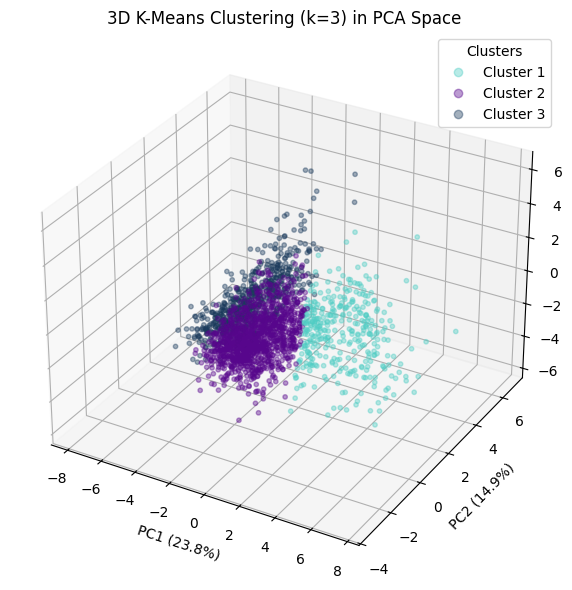

In [9]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                     c=KM_FINAL.labels_, cmap=custom_cmap, alpha=0.4, s=10)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')

ax.set_title(f'3D K-Means Clustering (k={K_CHOSEN}) in PCA Space')

handles, labels = scatter.legend_elements()
legend_labels = [f"Cluster {i+1}" for i in range(K_CHOSEN)]
ax.legend(handles, legend_labels, title="Clusters")

plt.tight_layout()
# plt.savefig('scatter_pca_clusters_3d.png', dpi=150)
plt.show()

### 5. Interpretation of K-Means

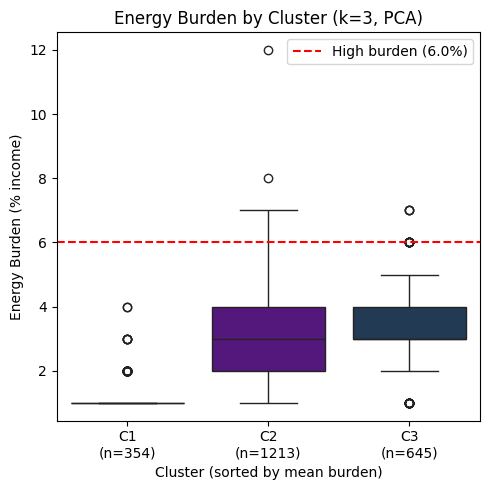


--- Cluster Statistics Summary ---
          count  mean   std  min  25%  50%  75%   max
cluster                                              
1         354.0  1.17  0.45  1.0  1.0  1.0  1.0   4.0
2        1213.0  2.97  1.20  1.0  2.0  3.0  4.0  12.0
3         645.0  3.38  0.97  1.0  3.0  3.0  4.0   7.0


In [10]:
tmp = pd.DataFrame({'cluster': KM_FINAL.labels_, TARGET: y})
order = tmp.groupby('cluster')[TARGET].mean().sort_values().index

plt.figure(figsize=(5, 5))

sns.boxplot(
    data=tmp, x='cluster', y=TARGET, order=order, 
    hue='cluster', palette=custom_cmap, dodge=False, legend=False
)

plt.axhline(HIGH_BURDEN, color='red', ls='--', label=f'High burden ({HIGH_BURDEN}%)')

plt.gca().set(
    xticks=range(K_CHOSEN),
    xticklabels=[f"C{i+1}\n(n={(tmp.cluster == c).sum()})" for i, c in enumerate(order)],
    xlabel='Cluster (sorted by mean burden)',
    ylabel='Energy Burden (% income)',
    title=f'Energy Burden by Cluster (k={K_CHOSEN}, PCA)'
)

plt.legend() # Only the axhline remains, so no complex filtering is needed
plt.tight_layout()
# plt.savefig('boxplot.png', dpi=150)
plt.show()

print("\n--- Cluster Statistics Summary ---")
print(tmp.groupby('cluster')[TARGET].describe().loc[order].round(2))

All Feature Importance  (k = 3 )

1. pct_renter   F = 1380.08   p = 0.0   sig: yes
2. pluto_mean_builtfar   F = 1005.58   p = 0.0   sig: yes
3. median_income   F = 988.88   p = 0.0   sig: yes
4. subway_05mi   F = 731.04   p = 0.0   sig: yes
5. pluto_resarea_per_unit   F = 548.71   p = 0.0   sig: yes
6. pluto_bldgarea_per_unit   F = 410.67   p = 0.0   sig: yes
7. avg_hh_size   F = 383.56   p = 0.0   sig: yes
8. bus_025mi   F = 352.96   p = 0.0   sig: yes
9. Total Households   F = 289.04   p = 0.0   sig: yes
10. pct_nonwhite   F = 230.92   p = 0.0   sig: yes
11. pct_rent_burdened   F = 206.24   p = 0.0   sig: yes
12. pluto_mean_yearbuilt   F = 176.9   p = 0.0   sig: yes
13. canopy_temp_diff   F = 144.0   p = 0.0   sig: yes
14. canopy_treecanopy   F = 70.79   p = 0.0   sig: yes
15. pluto_avg_lotarea   F = 38.88   p = 0.0   sig: yes
16. pluto_commercial_share   F = 26.57   p = 0.0   sig: yes
17. pluto_pct_residential   F = nan   p = nan   sig: no


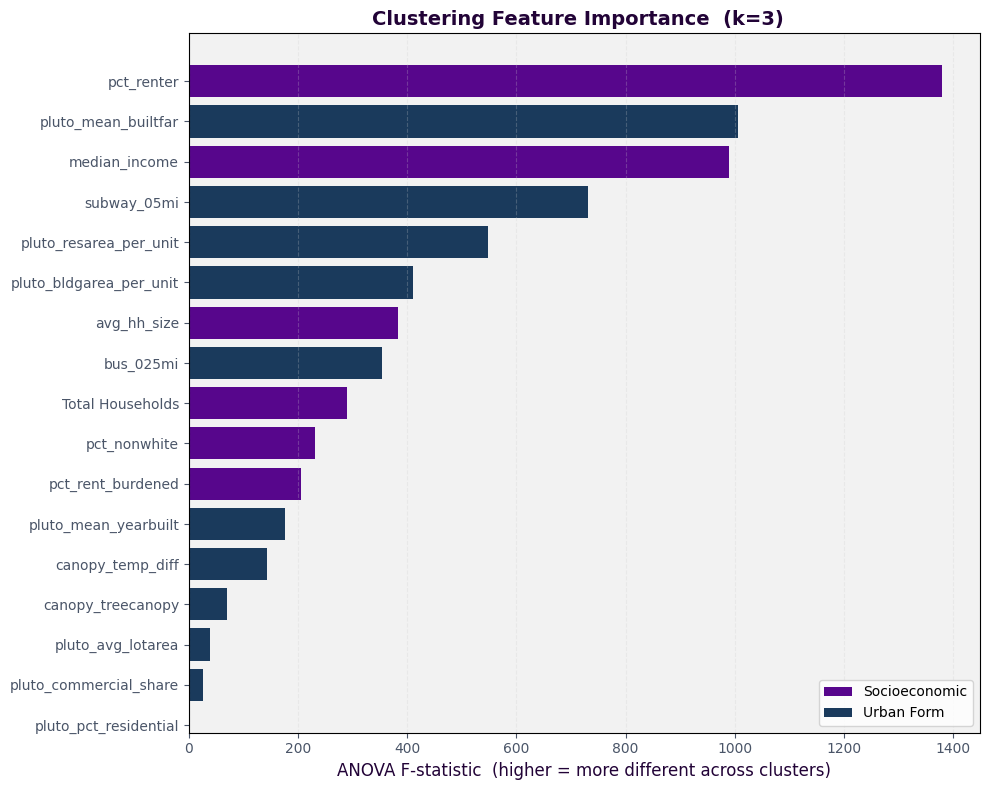


Top significant features: ['pct_renter', 'pluto_mean_builtfar', 'median_income', 'subway_05mi', 'pluto_resarea_per_unit', 'pluto_bldgarea_per_unit', 'avg_hh_size']


In [11]:
features, f_stats, p_vals = [], [], []

for feat in feature_cols:
    groups  = [X_imp.loc[KM_FINAL.labels_ == c, feat].values for c in np.unique(KM_FINAL.labels_)]
    f_val, p_val = f_oneway(*groups)
    features.append(feat)
    f_stats.append(round(f_val, 2))
    p_vals.append(round(p_val, 6))

fi_df = pd.DataFrame({'Feature': features, 'F_stat': f_stats, 'p_value': p_vals})
fi_df = fi_df.sort_values('F_stat', ascending=False).reset_index(drop=True)
fi_df['Significant'] = fi_df['p_value'] < 0.05

print('All Feature Importance  (k =', K_CHOSEN, ')\n')
for i, row in fi_df.iterrows():
    sig = 'yes' if row['Significant'] else 'no'
    print(str(i+1) + '.', row['Feature'], '  F =', row['F_stat'], '  p =', row['p_value'], '  sig:', sig)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

colors = ['#57068C' if feat in socio_cols else '#1A3A5C' for feat in fi_df['Feature']]

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#57068C', label='Socioeconomic'),
    Patch(facecolor='#1A3A5C', label='Urban Form'),
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.8, edgecolor='#CCCCCC')

plt.barh(fi_df['Feature'][::-1], fi_df['F_stat'][::-1], color=colors[::-1])
plt.xlabel('ANOVA F-statistic  (higher = more different across clusters)',fontsize=12, color='#220337')
plt.title('Clustering Feature Importance  (k=' + str(K_CHOSEN) + ')  ', fontsize=14, fontweight='bold', color='#220337')
plt.grid(axis='x', linestyle='--', alpha=0.25, color='#CCCCCC')
plt.tick_params(colors='#4A5568')
plt.tight_layout()
# plt.savefig('all_importance.png', dpi=150)
plt.show()

TOP_FEATURES = fi_df[fi_df['Significant']]['Feature'].head(7).tolist()
print('\nTop significant features:', TOP_FEATURES)

Socio Feature Importance  (k = 3 )

1. pct_renter   F = 1380.08   p = 0.0   sig: yes
2. median_income   F = 988.88   p = 0.0   sig: yes
3. avg_hh_size   F = 383.56   p = 0.0   sig: yes
4. Total Households   F = 289.04   p = 0.0   sig: yes
5. pct_nonwhite   F = 230.92   p = 0.0   sig: yes
6. pct_rent_burdened   F = 206.24   p = 0.0   sig: yes


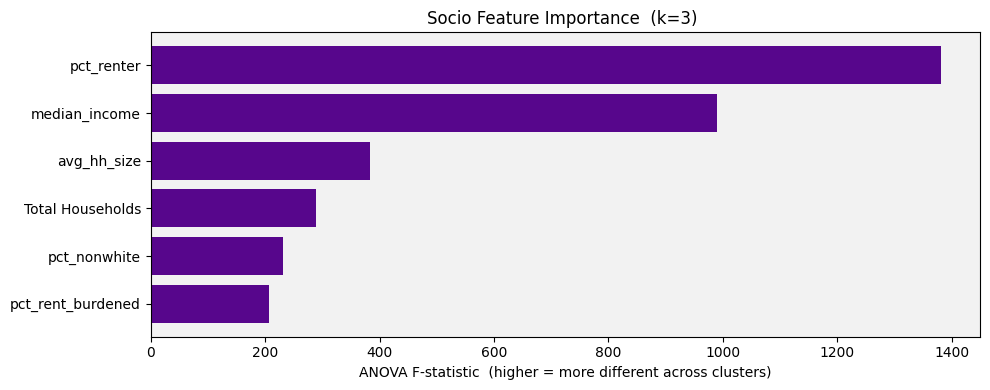


Top significant socio features: ['pct_renter', 'median_income', 'avg_hh_size', 'Total Households', 'pct_nonwhite', 'pct_rent_burdened']


In [53]:
features, f_stats, p_vals = [], [], []

for feat in socio_cols:
    groups  = [X_imp.loc[KM_FINAL.labels_ == c, feat].values for c in np.unique(KM_FINAL.labels_)]
    f_val, p_val = f_oneway(*groups)
    features.append(feat)
    f_stats.append(round(f_val, 2))
    p_vals.append(round(p_val, 6))

fi_df = pd.DataFrame({'Feature': features, 'F_stat': f_stats, 'p_value': p_vals})
fi_df = fi_df.sort_values('F_stat', ascending=False).reset_index(drop=True)
fi_df['Significant'] = fi_df['p_value'] < 0.05

print('Socio Feature Importance  (k =', K_CHOSEN, ')\n')
for i, row in fi_df.iterrows():
    sig = 'yes' if row['Significant'] else 'no'
    print(str(i+1) + '.', row['Feature'], '  F =', row['F_stat'], '  p =', row['p_value'], '  sig:', sig)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

colors = ['#57068C' if s else 'red' for s in fi_df['Significant']]

plt.barh(fi_df['Feature'][::-1], fi_df['F_stat'][::-1], color=colors[::-1])
plt.xlabel('ANOVA F-statistic  (higher = more different across clusters)')
plt.title('Socio Feature Importance  (k=' + str(K_CHOSEN) + ') ')
plt.tight_layout()
plt.show()

TOP_SOCIO = fi_df[fi_df['Significant']]['Feature'].head(7).tolist()
print('\nTop significant socio features:', TOP_SOCIO)

Non-Socio Feature Importance  (k = 3 )

1. pluto_mean_builtfar   F = 1005.58   p = 0.0   sig: yes
2. subway_05mi   F = 731.04   p = 0.0   sig: yes
3. pluto_resarea_per_unit   F = 548.71   p = 0.0   sig: yes
4. pluto_bldgarea_per_unit   F = 410.67   p = 0.0   sig: yes
5. bus_025mi   F = 352.96   p = 0.0   sig: yes
6. pluto_mean_yearbuilt   F = 176.9   p = 0.0   sig: yes
7. canopy_temp_diff   F = 144.0   p = 0.0   sig: yes
8. canopy_treecanopy   F = 70.79   p = 0.0   sig: yes
9. pluto_avg_lotarea   F = 38.88   p = 0.0   sig: yes
10. pluto_commercial_share   F = 26.57   p = 0.0   sig: yes
11. pluto_pct_residential   F = nan   p = nan   sig: no


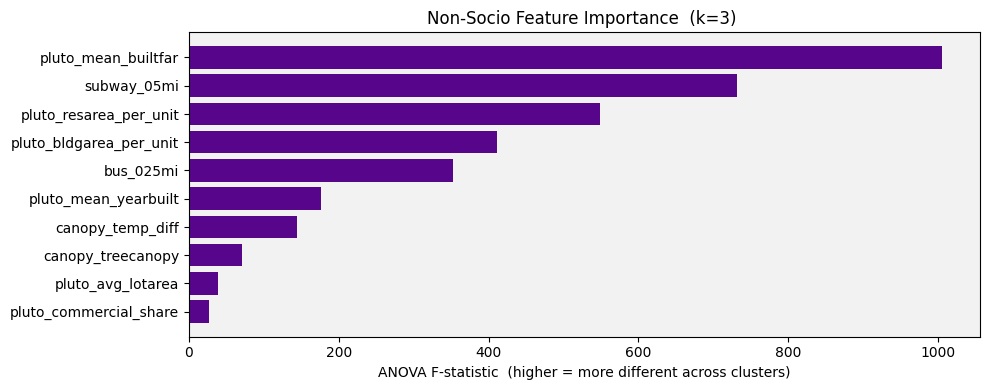


Top significant non-socio features: ['pluto_mean_builtfar', 'subway_05mi', 'pluto_resarea_per_unit', 'pluto_bldgarea_per_unit', 'bus_025mi', 'pluto_mean_yearbuilt', 'canopy_temp_diff']


In [55]:
features, f_stats, p_vals = [], [], []

for feat in non_socio_cols:
    groups  = [X_imp.loc[KM_FINAL.labels_ == c, feat].values for c in np.unique(KM_FINAL.labels_)]
    f_val, p_val = f_oneway(*groups)
    features.append(feat)
    f_stats.append(round(f_val, 2))
    p_vals.append(round(p_val, 6))

fi_df = pd.DataFrame({'Feature': features, 'F_stat': f_stats, 'p_value': p_vals})
fi_df = fi_df.sort_values('F_stat', ascending=False).reset_index(drop=True)
fi_df['Significant'] = fi_df['p_value'] < 0.05

print('Non-Socio Feature Importance  (k =', K_CHOSEN, ')\n')
for i, row in fi_df.iterrows():
    sig = 'yes' if row['Significant'] else 'no'
    print(str(i+1) + '.', row['Feature'], '  F =', row['F_stat'], '  p =', row['p_value'], '  sig:', sig)


fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

colors = ['#57068C' if s else 'red' for s in fi_df['Significant']]

plt.barh(fi_df['Feature'][::-1], fi_df['F_stat'][::-1], color=colors[::-1])
plt.xlabel('ANOVA F-statistic  (higher = more different across clusters)')
plt.title('Non-Socio Feature Importance  (k=' + str(K_CHOSEN) + ') ')
plt.tight_layout()
# plt.savefig('nonsocio_importance.png', dpi=150)
plt.show()

TOP_NONSOCIO = fi_df[fi_df['Significant']]['Feature'].head(7).tolist()
print('\nTop significant non-socio features:', TOP_NONSOCIO)

In [56]:
data['cluster_km'] = KM_FINAL.labels_  # Add cluster labels to data for borough grouping

if 'Borough' in data.columns:
    boro_dist = data.groupby('cluster_km')['Borough'].value_counts(normalize=True).unstack().fillna(0)
    print('\nBorough share per cluster (%):')
    data = data[data[TARGET].notna() & (data[TARGET] > 0)].reset_index(drop=True)
    print('\nBorough share per cluster (sorted by energy burden, %):')
    print((boro_dist * 100).round(1).to_string())


Borough share per cluster (%):

Borough share per cluster (sorted by energy burden, %):
Borough     Bronx  Brooklyn  Manhattan  Queens  Staten Island
cluster_km                                                   
1             0.0      28.8       63.8     7.3            0.0
2            23.3      43.8        5.4    26.4            1.1
3             9.5      22.2        0.2    51.5           16.7


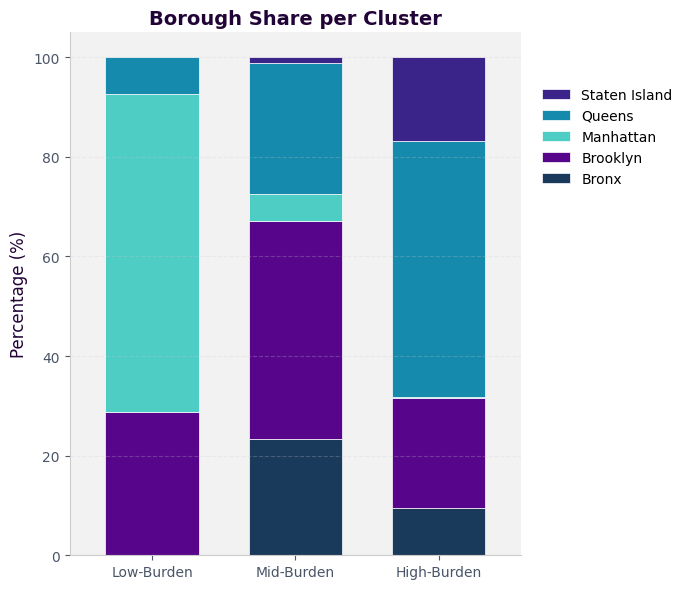

In [92]:
import matplotlib.pyplot as plt

boro_dist = data.groupby('cluster_km')['Borough'].value_counts(normalize=True).unstack().fillna(0)
boro_dist_pct = boro_dist * 100

boro_dist_pct.index = ['Low-Burden', 'Mid-Burden', 'High-Burden']

ordered_boroughs = ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
ordered_boroughs = [b for b in ordered_boroughs if b in boro_dist_pct.columns]
boro_dist_pct = boro_dist_pct[ordered_boroughs]

boro_colors = {
    'Bronx': '#1A3A5C',          # Light Blue
    'Brooklyn': '#57068C',       # Muted Red
    'Manhattan': '#4ECDC4',      # Light Yellow
    'Queens': '#168AAD',         # Light Green
    'Staten Island': '#3A2489'   # Muted Purple
}
colors = [boro_colors[b] for b in ordered_boroughs]

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F2F2F2')

boro_dist_pct.plot(
    kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5, width=0.65
)
ax.set_ylabel('Percentage (%)', fontsize=12, color='#220337')
ax.set_title('Borough Share per Cluster', fontsize=14, fontweight='bold', color='#220337')

ax.grid(axis='y', linestyle='--', alpha=0.25, color='#CCCCCC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

ax.tick_params(colors='#4A5568', labelrotation=0) 

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='center left', bbox_to_anchor=(1.02, 0.8),fontsize=10, framealpha=0.8, edgecolor='white')

plt.tight_layout()
plt.show()

In [57]:
HIGH_BURDEN = 6.0 # Threshold for high energy burden

pf = X_imp.copy()
pf['cluster_km'] = KM_FINAL.labels_
pf[TARGET] = y

burden_order = pf.groupby('cluster_km')[TARGET].mean().sort_values().index.tolist()

arch_map = {
    2: ['Low-Burden', 'High-Burden'],
    3: ['Low-Burden', 'Mid-Burden', 'High-Burden'],
    4: ['Low-Burden', 'Mid-Low', 'Mid-High', 'High-Burden'],
}
arch_names = arch_map.get(K_CHOSEN, ['Type-' + str(i+1) for i in range(K_CHOSEN)])

profile_rows = []

for rank, c in enumerate(burden_order):
    mask    = KM_FINAL.labels_ == c
    n       = int(mask.sum())
    burden  = y[mask]
    name    = arch_names[rank]
    hb_rate = (burden > HIGH_BURDEN).mean() * 100

    print('=== Cluster', c, ':', name, '  (n=' + str(n) + ',', str(round(n/len(y)*100, 1)) + '%) ===')
    print('  Burden: mean =', round(burden.mean(), 2),
          '%  median =', round(float(np.median(burden)), 2),
          '%  std =', round(burden.std(), 2), '%')
    print('  High-burden rate (>', HIGH_BURDEN, '%) :', round(hb_rate, 1), '%')

    print('  Socio:')
    for feat in TOP_SOCIO:
        val   = X_imp.loc[mask, feat].mean()
        avg   = X_imp[feat].mean()
        diff  = (val - avg) / avg * 100 if avg != 0 else 0
        arrow =  '↑'  if diff > 5 else ( '↓'  if diff < -5 else '~')
        print('   ', feat + ':', round(val, 1), ' (' + arrow, str(round(diff)) + '% vs NYC)')

    if TOP_NONSOCIO:
        print('  Top non-socio:')
        for feat in TOP_NONSOCIO:
            val   = X_imp.loc[mask, feat].mean()
            avg   = X_imp[feat].mean()
            diff  = (val - avg) / avg * 100 if avg != 0 else 0
            arrow =  '↑'  if diff > 5 else ( '↓'  if diff < -5 else '~')
            print('   ', feat + ':', round(val, 3), ' (' + arrow, str(round(diff)) + '% vs NYC)')
    print()

    profile_rows.append({'Cluster': c, 'Archetype': name, 'n': n,
                         'burden_mean': round(burden.mean(), 3),
                         'high_burden_pct': round(hb_rate, 1)})

=== Cluster 1 : Low-Burden   (n=354, 16.0%) ===
  Burden: mean = 1.17 %  median = 1.0 %  std = 0.45 %
  High-burden rate (> 6.0 %) : 0.0 %
  Socio:
    pct_renter: 0.7  (↑ 12% vs NYC)
    median_income: 125796.4  (↑ 61% vs NYC)
    avg_hh_size: 2.1  (↓ -26% vs NYC)
    Total Households: 2334.3  (↑ 57% vs NYC)
    pct_nonwhite: 0.4  (↓ -40% vs NYC)
    pct_rent_burdened: 0.4  (↓ -22% vs NYC)
  Top non-socio:
    pluto_mean_builtfar: 4.365  (↑ 142% vs NYC)
    subway_05mi: 5.073  (↑ 141% vs NYC)
    pluto_resarea_per_unit: 0.701  (↓ -96% vs NYC)
    pluto_bldgarea_per_unit: 0.277  (↓ -97% vs NYC)
    bus_025mi: 19.311  (↑ 56% vs NYC)
    pluto_mean_yearbuilt: 1924.559  (~ -1% vs NYC)
    canopy_temp_diff: 5.464  (↓ -29% vs NYC)

=== Cluster 2 : Mid-Burden   (n=1213, 54.8%) ===
  Burden: mean = 2.97 %  median = 3.0 %  std = 1.2 %
  High-burden rate (> 6.0 %) : 0.6 %
  Socio:
    pct_renter: 0.8  (↑ 21% vs NYC)
    median_income: 56810.4  (↓ -27% vs NYC)
    avg_hh_size: 2.9  (~ 3% vs NYC)

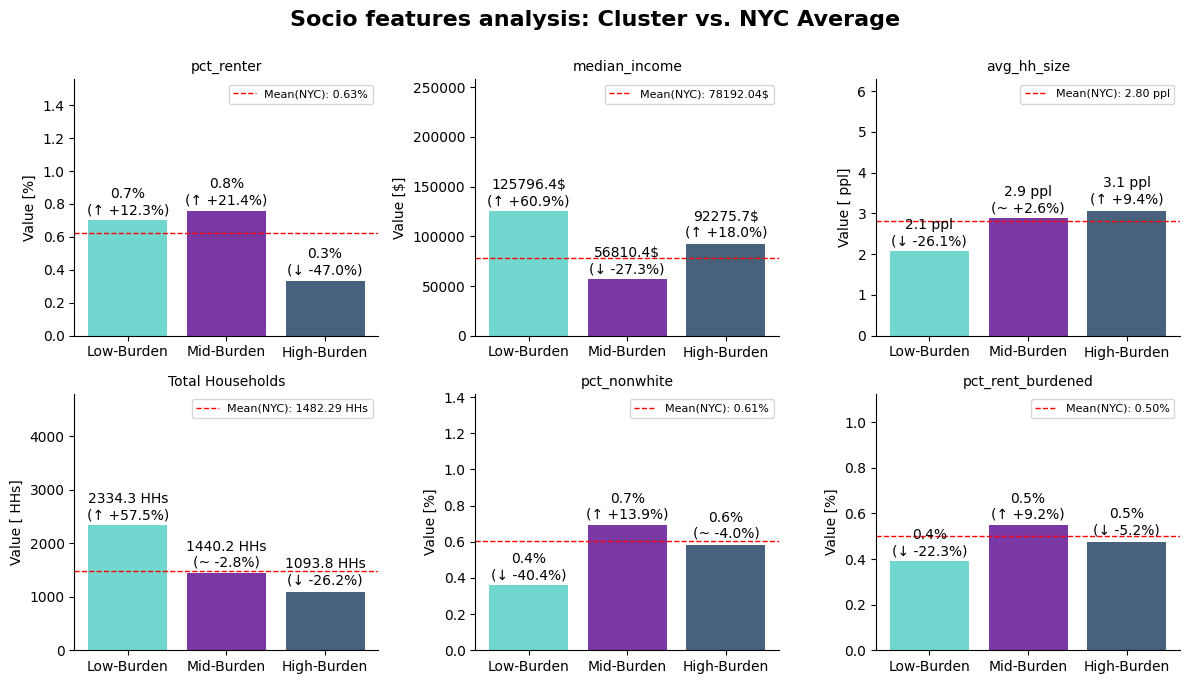

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

feature_units = {
    'median_income': '$',
    'avg_hh_size': ' ppl',
    'Total Households': ' HHs',
    'pct_nonwhite': '%',
    'pct_rent_burdened': '%',
    'pct_renter': '%'
}

plot_data = []

for rank, c in enumerate(burden_order):
    mask = KM_FINAL.labels_ == c
    name = arch_names[rank]

    for feat in TOP_SOCIO:
        if feat in X_imp.columns:
            val = X_imp.loc[mask, feat].mean()
            avg = X_imp[feat].mean()
            diff = (val - avg) / avg * 100 if avg != 0 else 0
            
            plot_data.append({
                'Archetype': name,
                'Cluster': c,
                'Feature': feat,
                'Cluster_Value': val,
                'Overall_Mean': avg,
                'Pct_Diff': diff,
                'Category': 'Socio'
            })

df_viz = pd.DataFrame(plot_data)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 7))
axes = axes.flatten()

colors = sns.color_palette("Set2", len(arch_names))

for i, ax in enumerate(axes):
    if i < len(TOP_SOCIO):
        feat = TOP_SOCIO[i]
        subset = df_viz[df_viz['Feature'] == feat]
        
        if subset.empty:
            ax.set_visible(False)
            continue
            
        overall_mean = subset['Overall_Mean'].iloc[0]
        unit = feature_units.get(feat, '') 
        
        bars = ax.bar(subset['Archetype'], subset['Cluster_Value'], color=custom_colors, alpha=0.8)
        
        ax.axhline(y=overall_mean, color='red', linestyle='--', linewidth=1, label=f'Mean(NYC): {overall_mean:.2f}{unit}')
        
        ax.set_title(f"{feat}", fontsize=10)
        ax.set_ylabel(f"Value [{unit}]" if unit.strip() else "Value")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='best', fontsize=8)
        
        
        for bar, pct_diff, actual_val in zip(bars, subset['Pct_Diff'], subset['Cluster_Value']):
            height = bar.get_height()
            label_y = height + (ax.get_ylim()[1] * 0.02)
            
            arrow = '↑' if pct_diff > 5 else ('↓' if pct_diff < -5 else '~')
            diff_str = f"({arrow} {pct_diff:+.1f}%)" if pd.notnull(pct_diff) else ""
            
            val_str = f"{actual_val:.1f}"
            annotation = f"{val_str}{unit}\n{diff_str}"
            
            ax.text(bar.get_x() + bar.get_width()/2, label_y, annotation, 
                    va='bottom', ha='center', fontsize=10, color='black')
            ax.set_ylim(0, ax.get_ylim()[1] * 1.25)
            
    else:
        ax.set_visible(False)

plt.suptitle("Socio features analysis: Cluster vs. NYC Average", fontsize=16, y=0.97, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

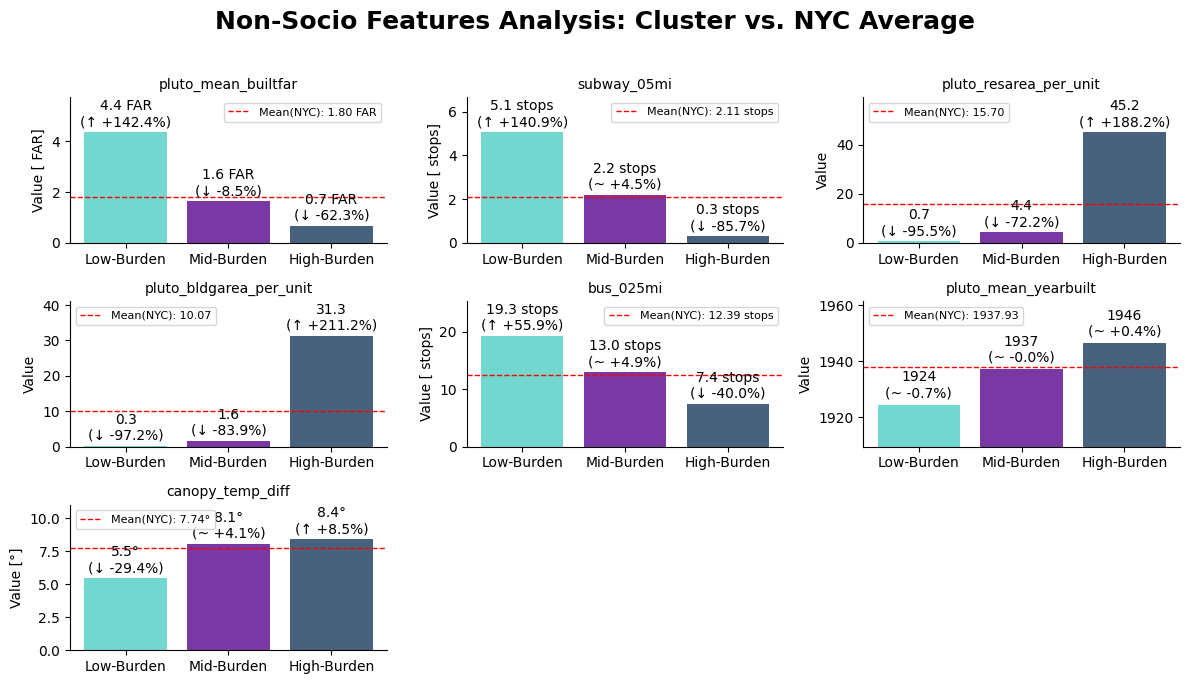

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

feature_units = {
    'pluto_mean_builtfar': ' FAR',
    'subway_05mi': ' stops',
    'bus_025mi': ' stops',
    'canopy_temp_diff': '°',           
    'pluto_mean_yearbuilt': '',         
    'pluto_mean_effective_year': '',
    'pluto_pct_historic': '%'
}

plot_data = []

for rank, c in enumerate(burden_order):
    mask = KM_FINAL.labels_ == c
    name = arch_names[rank]

    for feat in TOP_NONSOCIO:
        if feat in X_imp.columns:
            val = X_imp.loc[mask, feat].mean()
            avg = X_imp[feat].mean()
            diff = (val - avg) / avg * 100 if avg != 0 else 0
            
            plot_data.append({
                'Archetype': name,
                'Cluster': c,
                'Feature': feat,
                'Cluster_Value': val,
                'Overall_Mean': avg,
                'Pct_Diff': diff,
                'Category': 'Non-Socio'
            })

df_viz = pd.DataFrame(plot_data)

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 7))
axes = axes.flatten()

colors = sns.color_palette("Set2", len(arch_names))

for i, ax in enumerate(axes):
    if i < len(TOP_NONSOCIO):
        feat = TOP_NONSOCIO[i]
        subset = df_viz[df_viz['Feature'] == feat]
        
        if subset.empty:
            ax.set_visible(False)
            continue
            
        overall_mean = subset['Overall_Mean'].iloc[0]
        unit = feature_units.get(feat, '') 
        
        bars = ax.bar(subset['Archetype'], subset['Cluster_Value'], color=custom_colors, alpha=0.8)
        
        # Add a horizontal dashed line for the overall NYC mean
        ax.axhline(y=overall_mean, color='red', linestyle='--', linewidth=1, 
                   label=f'Mean(NYC): {overall_mean:.2f}{unit}')
        
        # Formatting the subplot
        ax.set_title(f"{feat}", fontsize=10)
        ax.set_ylabel(f"Value [{unit}]" if unit.strip() else "Value")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='best', fontsize=8)
        
        is_year_feature = 'year' in feat.lower()
        
        # Fix the Y-axis limits FIRST
        if is_year_feature:
            min_val = subset['Cluster_Value'].min()
            max_val = subset['Cluster_Value'].max()
            ax.set_ylim(min_val - 15, max_val + 15) # Keep a tight window for years
        else:
            ax.set_ylim(0, ax.get_ylim()[1] * 1.25) # Standard scaling for everything else
        
        for bar, pct_diff, actual_val in zip(bars, subset['Pct_Diff'], subset['Cluster_Value']):
            height = bar.get_height()
            
            if is_year_feature:
                label_y = height + 1.5 # Add exactly 1.5 years of padding above the bar
            else:
                label_y = height + (ax.get_ylim()[1] * 0.02)
            
            arrow = '↑' if pct_diff > 5 else ('↓' if pct_diff < -5 else '~')
            diff_str = f"({arrow} {pct_diff:+.1f}%)" if pd.notnull(pct_diff) else ""
            
            if is_year_feature:
                val_str = f"{int(actual_val)}"
            else:
                val_str = f"{actual_val:.1f}"
                
            annotation = f"{val_str}{unit}\n{diff_str}"
            
            ax.text(bar.get_x() + bar.get_width()/2, label_y, annotation, 
                    va='bottom', ha='center', fontsize=10, color='black')
            
    else:
        ax.set_visible(False)

plt.suptitle("Non-Socio Features Analysis: Cluster vs. NYC Average", fontsize=18, y=0.97, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

### Appendix. Other clustering method test (GMM, Hierarchical clustering methods)

In [17]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

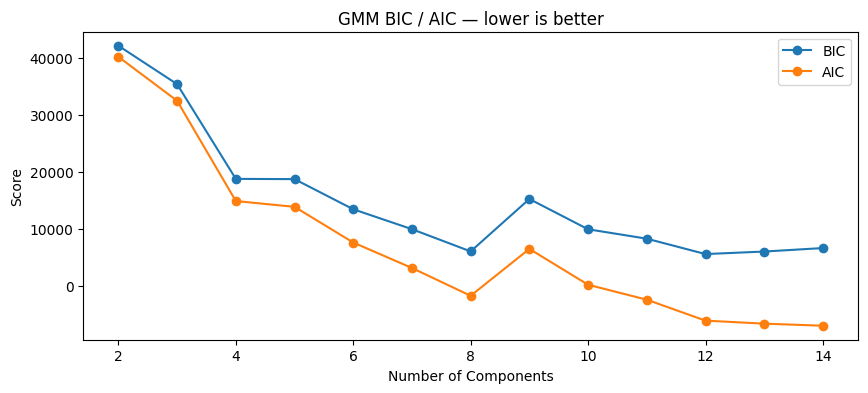

In [61]:
bic_scores = []
aic_scores = []

for n in range(2, 15):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

plt.figure(figsize=(10, 4))
plt.plot(range(2, 15), bic_scores, marker='o', label='BIC')
plt.plot(range(2, 15), aic_scores, marker='o', label='AIC')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('GMM BIC / AIC — lower is better')
plt.legend()
plt.show()

In [62]:
final_gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = final_gmm.fit_predict(X_scaled)
print('silhouette score:', silhouette_score(X_scaled, labels_gmm))

data['gmm_final'] = final_gmm.fit_predict(X_scaled)
print(data.groupby('gmm_final')['Energy Burden (% income)'].describe())

silhouette score: 0.017673067575931813
           count      mean       std  min  25%  50%  75%   max
gmm_final                                                     
0          596.0  3.239933  1.158592  1.0  2.0  3.0  4.0   8.0
1          396.0  3.492424  0.867088  1.0  3.0  3.0  4.0   7.0
2          254.0  2.440945  1.358059  1.0  1.0  2.0  3.0  12.0
3          966.0  2.338509  1.248546  1.0  1.0  2.0  3.0   7.0


1    2211
2       1
Name: count, dtype: int64


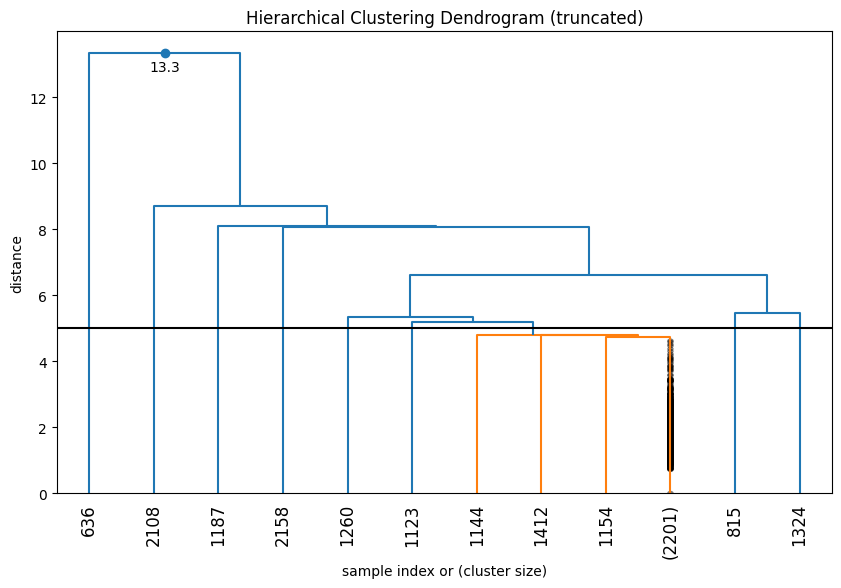

In [65]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

Z_single = linkage(X_scaled, 'single')

labels = fcluster(Z_single, 2, criterion='maxclust')
print(pd.Series(labels).value_counts())

def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

def distance_thr(Z, t, p):
    plt.figure(figsize=(10, 6))
    fancy_dendrogram(
        Z,
        truncate_mode='lastp',
        p=p,
        leaf_rotation=90.,
        leaf_font_size=12.,
        show_contracted=True,
        annotate_above=10,
        max_d=t,
    )
    plt.show()

distance_thr(Z_single, t=5, p=12)

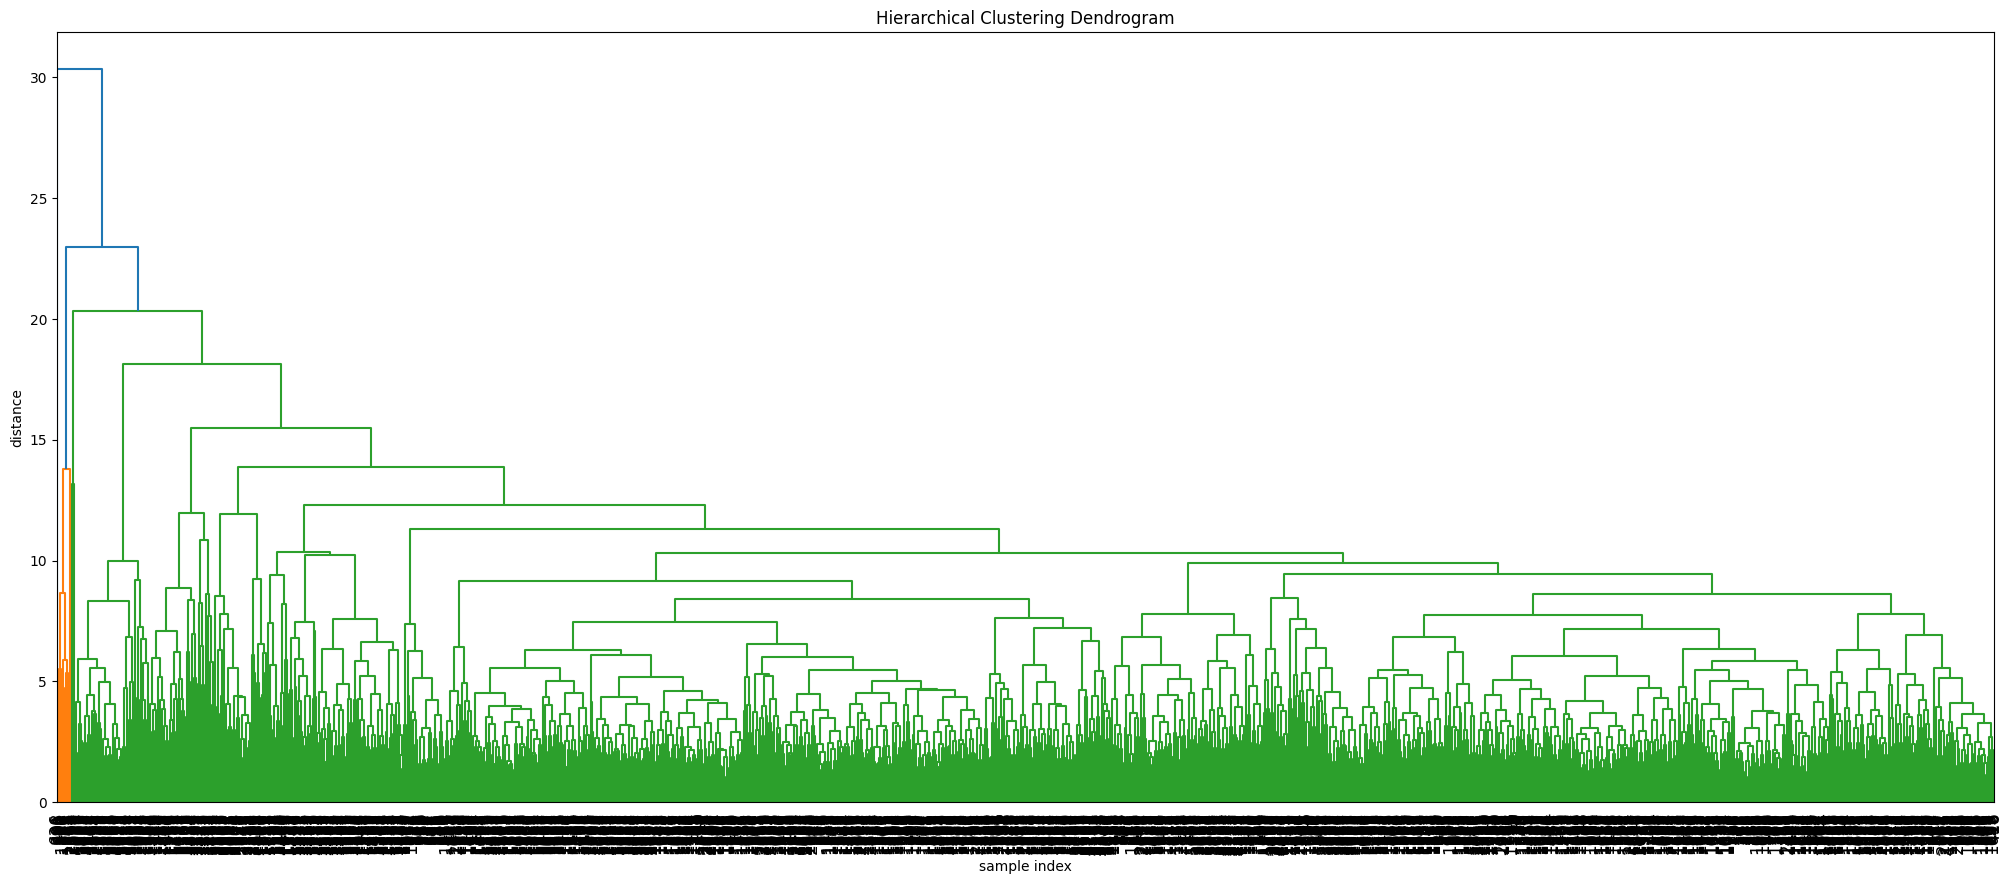

1    2211
2       1
Name: count, dtype: int64


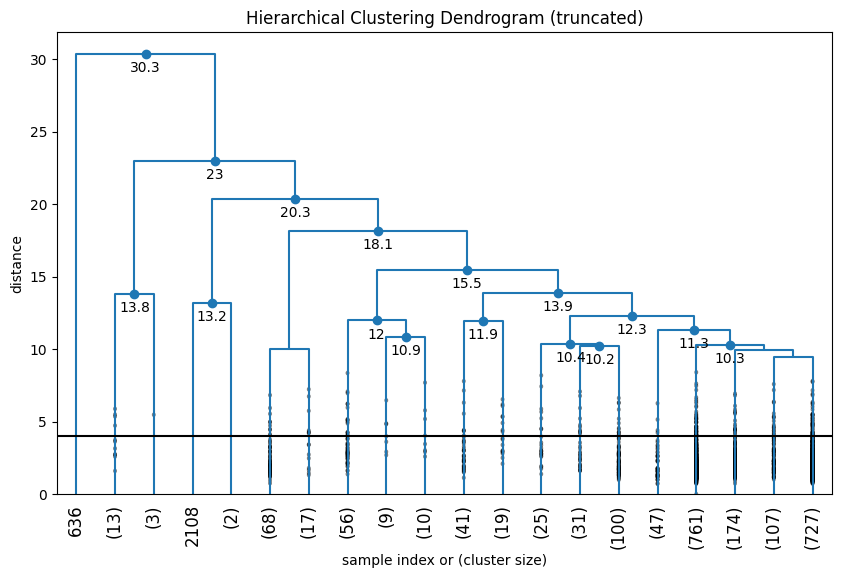

In [66]:
Z_complete = linkage(X_scaled, 'complete')

plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
dendrogram(
    Z_complete,
    leaf_rotation=90.,
    leaf_font_size=12.,
)
plt.show()

labels = fcluster(Z_complete, 2, criterion='maxclust')
print(pd.Series(labels).value_counts())

def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

def distance_thr(Z, t, p):
    plt.figure(figsize=(10, 6))
    fancy_dendrogram(
        Z,
        truncate_mode='lastp',
        p=p,
        leaf_rotation=90.,
        leaf_font_size=12.,
        show_contracted=True,
        annotate_above=10,
        max_d=t,
    )
    plt.show()

distance_thr(Z_complete, t=4, p=20)